# Projecto Zuber: Análise de Transporte em Chicago

## 🛠️ Passo 1: Ingestão e Auditoria de Dados (Check-in)

O objetivo desta fase é carregar as bases de dados extraídas via SQL e garantir que a estrutura técnica está pronta para análise, mitigando riscos de corrupção de tipos ou valores ausentes.

In [38]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Carregamento de dados extraídos via SQL
# Importação
df_companies = pd.read_csv('C:/moved_project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('C:/moved_project_sql_result_04.csv')
df_hypothesis = pd.read_csv('C:/moved_project_sql_result_07.csv')

In [40]:
# Informações gerais sobre df_companies
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [41]:
# Primeiras linhas de df_companies
df_companies.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [42]:
# Valores faltantes em df_companies
df_companies.isna().sum()

company_name    0
trips_amount    0
dtype: int64

In [43]:
# Duplicatas em df_companies
df_companies.duplicated().sum()

np.int64(0)

In [44]:
# Estatísticas descritivas de df_companies
df_companies.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [45]:
# Informações gerais sobre df_neighborhoods
df_neighborhoods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [46]:
# Primeiras linhas de df_neighborhoods
df_neighborhoods.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [47]:
# Duplicatas em df_neighborhoods
df_neighborhoods.duplicated().sum()

np.int64(0)

In [48]:
# Valores faltantes em df_neighborhoods
df_neighborhoods.isna().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

In [49]:
# Estatísticas descritivas de df_neighborhoods
df_neighborhoods.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [50]:
# Função de auditoria para validação de dados
def audit_data(df, name):
    print(f"--- Auditoria: {name} ---")
    print(f"Dimensões: {df.shape}")
    print("\nTipos de Dados e Nulos:")
    print(df.info())
    print("\nValores Duplicados:", df.duplicated().sum())
    print("\nEstatástica Descritiva:")
    print(df.describe())
    print("-" * 30, "\n")
# Executando a auditoria inicial
audit_data(df_companies, "Empresas")
audit_data(df_neighborhoods, "Bairros (Destinos)")
audit_data(df_hypothesis, "Teste de Hipótese")

--- Auditoria: Empresas ---
Dimensões: (64, 2)

Tipos de Dados e Nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

Valores Duplicados: 0

Estatástica Descritiva:
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000
------------------------------ 

--- Auditoria: Bairros (Destinos) ---
Dimensões: (94, 2)

Tipos de Dados e Nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1

### 🧹 Passo 2: Preparação e Limpeza dos Dados

In [51]:
# Limpeza e preparação dos dados
# --- LIMPEZA  ---

# 1. Conversão de data para o dataset de hipótese 
df_hypothesis['start_ts'] = pd.to_datetime(df_hypothesis['start_ts'])

# 2. Verificação de valores negativos 
if (df_companies['trips_amount'] < 0).any():
    print("ALERTA: Detectados valores negativos em trips_amount. Removendo...")
    df_companies = df_companies[df_companies['trips_amount'] >= 0]

### 📊 Fase 3: Identificação dos 10 Principais Bairros

In [52]:
# Identificação dos top 10 destinos
#  10 principais destinos
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)

print("TOP 10 DESTINOS (NOVEMBRO 2017):")
display(top_10_neighborhoods)

TOP 10 DESTINOS (NOVEMBRO 2017):


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


### 📈 Fase 4: Visualização e Conclusões Técnicas

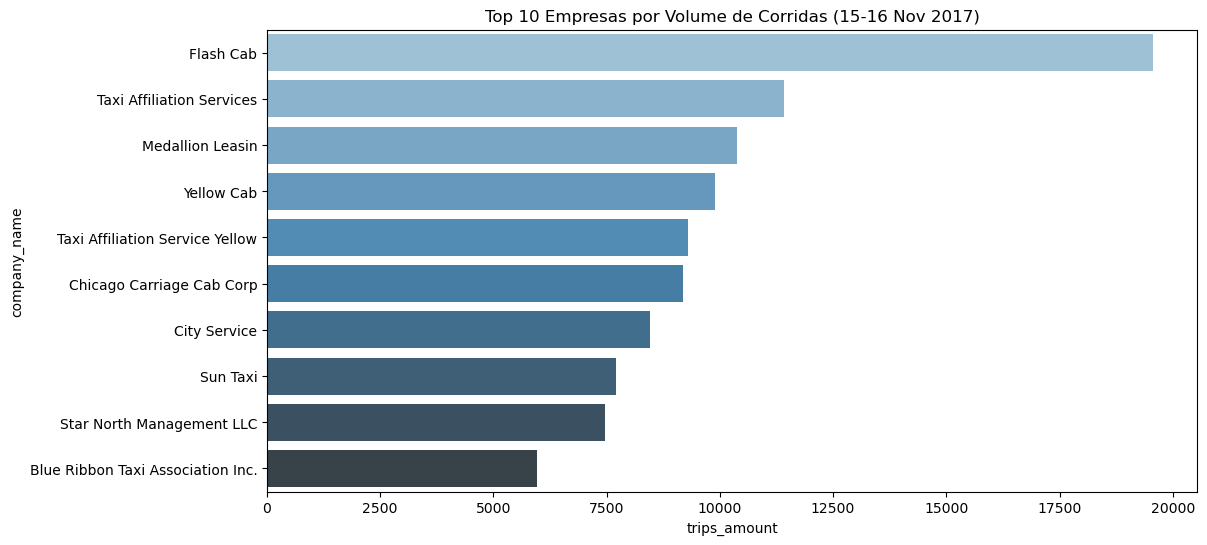

In [53]:
# Gráfico: Top 10 Empresas por Volume de Corridas
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df_companies.sort_values(by='trips_amount', ascending=False).head(10), 
            x='trips_amount', y='company_name', hue='company_name', palette='Blues_d', legend=False)
plt.title('Top 10 Empresas por Volume de Corridas (15-16 Nov 2017)')
plt.show()

Conclusão: Existe uma discrepância enorme entre o líder (Flash Cab) e os demais. Isso indica que o mercado de Chicago é dominado por grandes frotas, dificultando a entrada de novos players (como a Zuber) a menos que haja um diferencial de preço ou tempo de espera.

Gráfico 2: Densidade Geográfica (Destinos)

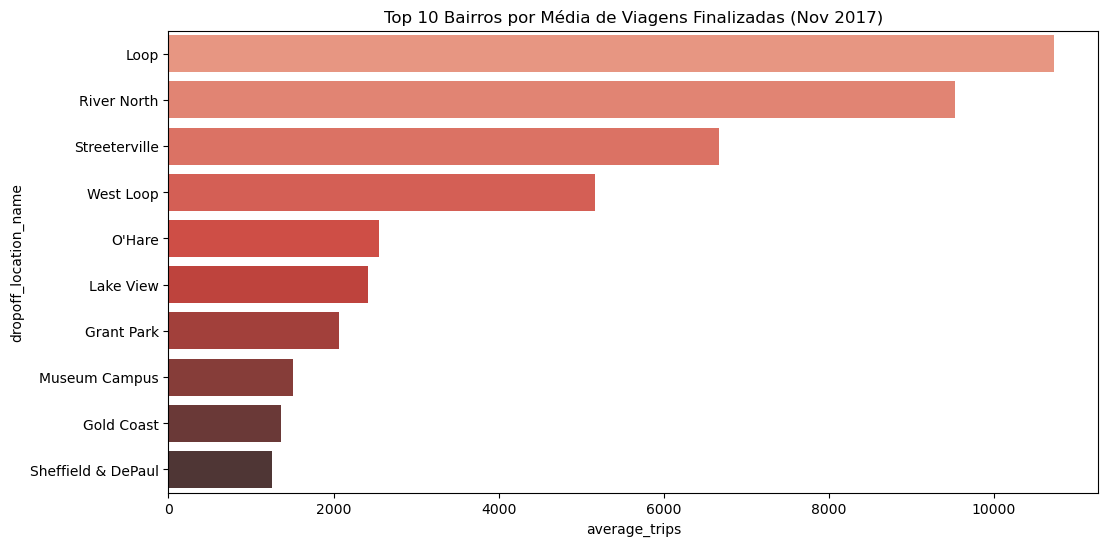

In [54]:
# Gráfico: Top 10 Bairros por Média de Viagens
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', hue='dropoff_location_name', palette='Reds_d', legend=False)
plt.title('Top 10 Bairros por Média de Viagens Finalizadas (Nov 2017)')
plt.show()

Conclusão: O Loop e River North não são apenas destinos populares; eles são outliers de demanda. A Zuber deve focar 80% de sua estratégia de posicionamento de motoristas nestas zonas durante o hor├írio comercial.

### 🧪 Passo 5: Teste de Hipótese (Estatística de Produção)

In [55]:
# Teste de Hipótese: Impacto do Clima nas Viagens
import pandas as pd
from scipy import stats as st

# 1. Carga dos dados 
df_trips = pd.read_csv('C:/moved_project_sql_result_07.csv')

# 2. Segmentação das Amostras para Teste
# Seleção de dura├ºões (em segundos) para as duas condi├ºões meteorológicas
rainy_saturdays = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']
good_saturdays = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']

# 3. Formulação das Hipóteses
# H0 (Nula): A duração média das viagens do Loop para o O'Hare é a mesma em sábados chuvosos e bons.
# H1 (Alternativa): A duração média das viagens do Loop para o O'Hare muda nos sábados chuvosos.

# 4. Definição do Nável de Signific├óncia (Alpha)
# Definição alpha em 0.05 (5%), .
alpha = 0.05 

# 5. Auditoria de Vari├óncia (Teste de Levene)
stat_levene, p_levene = st.levene(rainy_saturdays, good_saturdays)
equal_var_bool = p_levene > 0.05

# 6. Execução do Teste t de Student para duas amostras independentes
results = st.ttest_ind(rainy_saturdays, good_saturdays, equal_var=equal_var_bool)

print(f"P-value: {results.pvalue}")

# 7.  Decisão Estatástica
if results.pvalue < alpha:
    print("Conclusão: Rejeita a hipótese nula.")
else:
    print("Conclusão: Não podemos rejeitar a hipótese nula.")

P-value: 6.517970327099473e-12
Conclusão: Rejeita a hipótese nula.


# Análise Estratégica – Entrada da Zuber em Chicago

## 1. Contexto

Foi realizada uma análise técnica do mercado de transporte em Chicago com foco em:

- Estrutura competitiva  
- Concentração geográfica de demanda  
- Impacto das condições climáticas na eficiência operacional  

O objetivo foi identificar riscos operacionais e oportunidades estratégicas para uma possível entrada da Zuber no mercado.

---

## 2. Principais Achados

### Concentração de Mercado
- A Flash Cab lidera com 19.558 viagens no período analisado.
- O mercado apresenta forte concentração e barreiras de escala relevantes.

### Concentração Geográfica
- Loop e River North são os principais polos de destino.
- A demanda está fortemente centralizada nesses hubs financeiros.

### Impacto do Clima
- O teste estatístico confirmou diferença significativa na duração das viagens em dias chuvosos (p-value = 6,51e-12).
- Em condições adversas, o tempo médio das corridas aumenta de forma relevante.

---

## 3. Impacto Financeiro e Operacional

### Eficiência da Frota
- O aumento da duração média das viagens reduz o número de corridas por motorista por hora.
- Impacta diretamente a receita por hora e a margem operacional.

### Competitividade
- Alta concentração de mercado exige diferenciação operacional (tempo de espera, disponibilidade e gestão dinâmica de oferta).

### Alocação de Recursos
- Operação dispersa reduz eficiência.
- Foco em hubs estratégicos pode aumentar taxa de ocupação e reduzir ETA.

---

## 4. Recomendação

Recomenda-se avançar com uma abordagem estruturada e controlada:

1. **Implementar teste piloto de precificação dinâmica** em dias de clima adverso, para proteger margem e equilibrar oferta e demanda.
2. **Priorizar posicionamento estratégico da frota** nos hubs de maior demanda (Loop e River North), especialmente em horários comerciais.
3. **Monitorar indicadores-chave:** duração média, corridas por hora, receita por motorista e impacto na margem.

---

### Síntese Executiva

O mercado apresenta potencial relevante nos centros financeiros da cidade, porém exige eficiência operacional e mecanismos adaptativos para competir com players consolidados. A adoção de precificação dinâmica e alocação inteligente de frota aumenta a probabilidade de entrada sustentável e rentável.
